In [1]:
import pandas as pd
import requests

In [2]:
url = "https://api.spacexdata.com/v4/launches"

respuesta = requests.get(url)

datos = respuesta.json()

print("Cantidad de lanzamientos:", len(datos))

Cantidad de lanzamientos: 205


In [3]:
df = pd.DataFrame(datos)

df.head()

,fairings,links,static_fire_date_utc,static_fire_date_unix,net,window,rocket,success,failures,details,...,date_utc,date_unix,date_local,date_precision,upcoming,cores,auto_update,tbd,launch_library_id,id
0,"{'reused': False, 'recovery_attempt': False, '...",{'patch': {'small': 'https://images2.imgbox.co...,2006-03-17T00:00:00.000Z,1.142554e+09,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 33, 'altitude': None, 'reason': 'mer...",Engine failure at 33 seconds and loss of vehicle,...,2006-03-24T22:30:00.000Z,1143239400,2006-03-25T10:30:00+12:00,hour,False,"[{'core': '5e9e289df35918033d3b2623', 'flight'...",True,False,NaN,5eb87cd9ffd86e000604b32a
1,"{'reused': False, 'recovery_attempt': False, '...",{'patch': {'small': 'https://images2.imgbox.co...,NaN,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 301, 'altitude': 289, 'reason': 'har...",Successful first stage burn and transition to ...,...,2007-03-21T01:10:00.000Z,1174439400,2007-03-21T13:10:00+12:00,hour,False,"[{'core': '5e9e289ef35918416a3b2624', 'flight'...",True,False,NaN,5eb87cdaffd86e000604b32b
2,"{'reused': False, 'recovery_attempt': False, '...",{'patch': {'small': 'https://images2.imgbox.co...,NaN,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 140, 'altitude': 35, 'reason': 'resi...",Residual stage 1 thrust led to collision betwe...,...,2008-08-03T03:34:00.000Z,1217734440,2008-08-03T15:34:00+12:00,hour,False,"[{'core': '5e9e289ef3591814873b2625', 'flight'...",True,False,NaN,5eb87cdbffd86e000604b32c
3,"{'reused': False, 'recovery_attempt': False, '...",{'patch': {'small': 'https://images2.imgbox.co...,2008-09-20T00:00:00.000Z,1.221869e+09,False,0.0,5e9d0d95eda69955f709d1eb,True,[],Ratsat was carried to orbit on the first succe...,...,2008-09-28T23:15:00.000Z,1222643700,2008-09-28T11:15:00+12:00,hour,False,"[{'core': '5e9e289ef3591855dc3b2626', 'flight'...",True,False,NaN,5eb87cdbffd86e000604b32d
4,"{'reused': False, 'recovery_attempt': False, '...",{'patch': {'small': 'https://images2.imgbox.co...,NaN,NaN,False,0.0,5e9d0d95eda69955f709d1eb,True,[],NaN,...,2009-07-13T03:35:00.000Z,1247456100,2009-07-13T15:35:00+12:00,hour,False,"[{'core': '5e9e289ef359184f103b2627', 'flight'...",True,False,NaN,5eb87cdcffd86e000604b32e


In [4]:
df_modelo = df[['flight_number', 'success', 'upcoming']]

df_modelo.head()

,flight_number,success,upcoming
0,1,False,False
1,2,False,False
2,3,False,False
3,4,True,False
4,5,True,False


In [5]:
df_modelo['success'] = df_modelo['success'].fillna(0)

df_modelo['success'] = df_modelo['success'].astype(int)

df_modelo['upcoming'] = df_modelo['upcoming'].astype(int)

df_modelo.head()

,flight_number,success,upcoming
0,1,0,0
1,2,0,0
2,3,0,0
3,4,1,0
4,5,1,0


In [6]:
X = df_modelo[['flight_number', 'upcoming']]

y = df_modelo['success']

print(X.head())

print(y.head())

   flight_number  upcoming
0              1         0
1              2         0
2              3         0
3              4         0
4              5         0
0    0
1    0
2    0
3    1
4    1
Name: success, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Datos entrenamiento:", len(X_train))
print("Datos prueba:", len(X_test))

Datos entrenamiento: 164
Datos prueba: 41


In [8]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(random_state=42)

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [9]:
predicciones = modelo.predict(X_test)

print(predicciones[:10])

[1 1 1 1 1 1 1 1 1 1]


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predicciones)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [11]:
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test, predicciones)

print(matriz)

[[ 4  0]
 [ 0 37]]


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predicciones))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00        37

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



In [13]:
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree

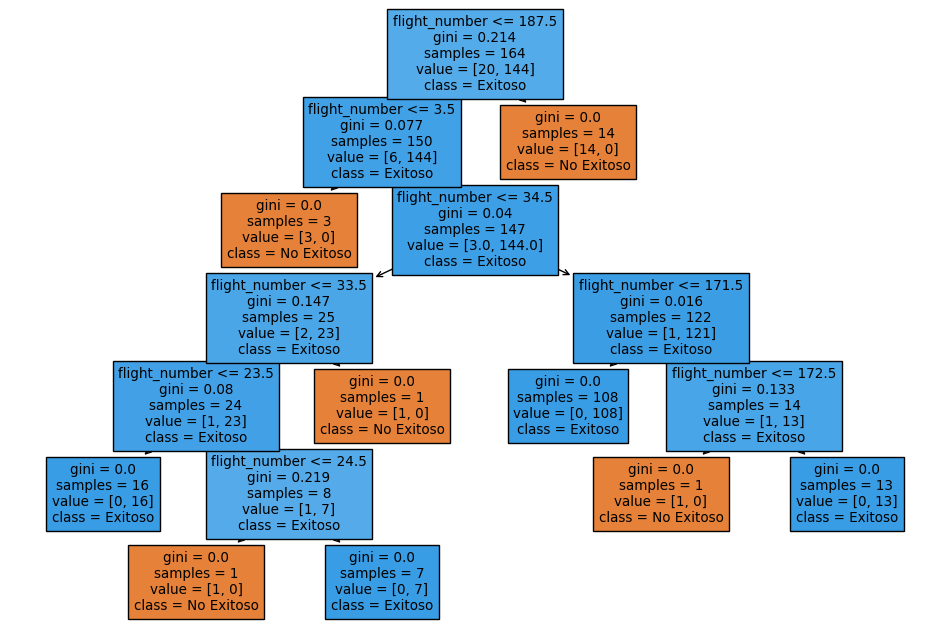

In [14]:
plt.figure(figsize=(12,8))

plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=['No Exitoso', 'Exitoso'],
    filled=True
)

plt.show()